# Mental Fitness Tracker

Predicting the mental fitness level of a country from the prevalence of different
mental and substance use disorders. Data comes from Our World in Data (IHME, Global
Burden of Disease study) and covers around 200 countries from 1990 to 2017.

The target here is the share of DALYs (disability adjusted life years) caused by
mental disorders, which I am treating as a "mental fitness" score for a country in
a given year. The features are the prevalence rates of seven disorders.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Reading the data

Two csv files, one with the DALY share (our target) and one with prevalence of each disorder.

In [2]:
df1 = pd.read_csv('data/mental-disease.csv')
df2 = pd.read_csv('data/prevalence-by-mental-and-substance-use-disorder.csv')
df1.head()

,Entity,Code,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
0,American Samoa,ASM,1990,1.696670
1,American Samoa,ASM,1991,1.734281
2,American Samoa,ASM,1992,1.791189
3,American Samoa,ASM,1993,1.776779
4,American Samoa,ASM,1994,1.712986


In [3]:
df2.head()

,Entity,Code,Year,Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent)
0,American samoa,ASM,1990,0.278979,0.721207,0.131001,4.835127,0.454202,5.125291,0.394036
1,American samoa,ASM,1991,0.268979,0.719952,0.126395,4.821765,0.397112,5.116306,0.394250
2,American samoa,ASM,1992,0.257328,0.718418,0.121832,4.801434,0.391190,5.106558,0.454550
3,American samoa,ASM,1993,0.256468,0.717452,0.117942,4.389363,0.395581,5.200328,0.395958
4,American samoa,ASM,1994,0.235567,0.717012,0.114547,4.184923,0.391822,5.799424,0.485779


## Merging the two datasets

Both files share Entity, Code and Year so a plain merge lines them up country by country, year by year.

In [4]:
data = pd.merge(df1, df2)
print(data.shape)
data.head()

(6750, 11)


,Entity,Code,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent),Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent)
0,African Region (WHO),NaN,1990,1.417621,0.216352,0.581938,0.102983,3.537832,0.437110,4.725167,1.152445
1,African Region (WHO),NaN,1991,1.433124,0.216379,0.582026,0.102086,3.535734,0.390948,4.715682,1.252155
2,African Region (WHO),NaN,1992,1.448188,0.216394,0.582084,0.101291,3.533891,0.394273,4.706978,1.348381
3,African Region (WHO),NaN,1993,1.457416,0.216392,0.582137,0.100536,3.532413,0.396924,4.699633,1.214318
4,African Region (WHO),NaN,1994,1.378090,0.216365,0.582201,0.099860,3.531429,0.398519,4.696143,1.240921


## Cleaning

In [5]:
data.isnull().sum()

Entity                                                                                               0
Code                                                                                               660
Year                                                                                                 0
DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)      0
Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent)                             0
Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent)                          0
Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent)                          0
Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent)                         0
Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent)                        0
Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Pe

In [6]:
# Code is just the country abbreviation, not useful for the model
data.drop('Code', axis=1, inplace=True)

# the original column names are way too long, shortening them
data = data.set_axis(['country', 'year', 'mental_fitness', 'schizophrenia',
                      'bipolar_disorder', 'eating_disorder', 'anxiety',
                      'drug_usage', 'depression', 'alcohol'], axis=1)
data.head()

,country,year,mental_fitness,schizophrenia,bipolar_disorder,eating_disorder,anxiety,drug_usage,depression,alcohol
0,African Region (WHO),1990,1.417621,0.216352,0.581938,0.102983,3.537832,0.437110,4.725167,1.152445
1,African Region (WHO),1991,1.433124,0.216379,0.582026,0.102086,3.535734,0.390948,4.715682,1.252155
2,African Region (WHO),1992,1.448188,0.216394,0.582084,0.101291,3.533891,0.394273,4.706978,1.348381
3,African Region (WHO),1993,1.457416,0.216392,0.582137,0.100536,3.532413,0.396924,4.699633,1.214318
4,African Region (WHO),1994,1.378090,0.216365,0.582201,0.099860,3.531429,0.398519,4.696143,1.240921


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6750 entries, 0 to 6749
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           6750 non-null   object 
 1   year              6750 non-null   int64  
 2   mental_fitness    6750 non-null   float64
 3   schizophrenia     6750 non-null   float64
 4   bipolar_disorder  6750 non-null   float64
 5   eating_disorder   6750 non-null   float64
 6   anxiety           6750 non-null   float64
 7   drug_usage        6750 non-null   float64
 8   depression        6750 non-null   float64
 9   alcohol           6750 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 527.5+ KB


## Exploratory data analysis

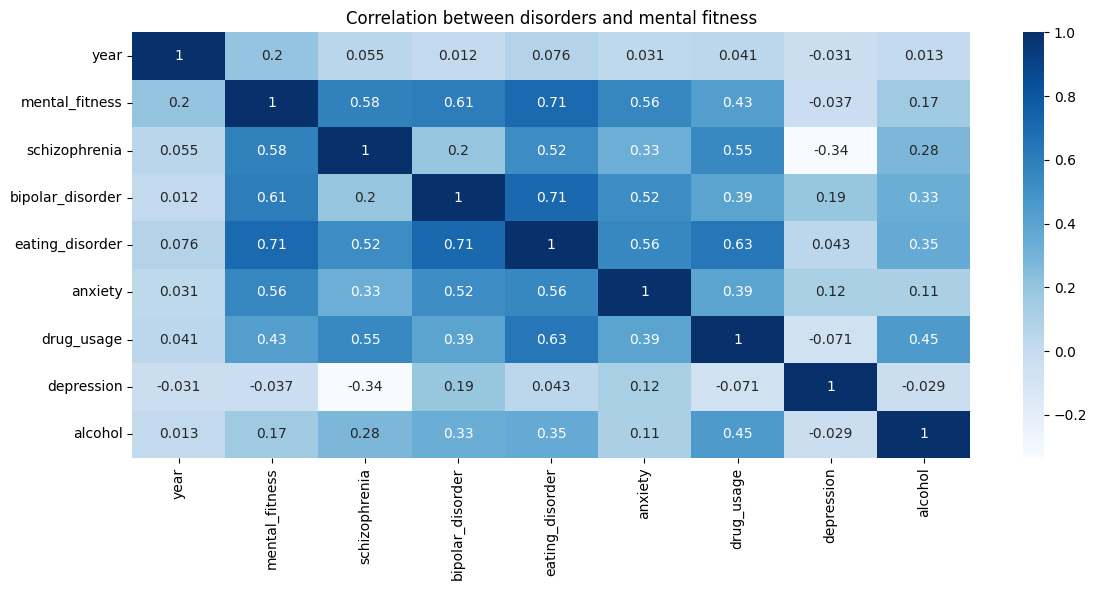

In [8]:
plt.figure(figsize=(12, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title('Correlation between disorders and mental fitness')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()

Depression and anxiety have the strongest positive correlation with the DALY share, which makes sense since they are the most common disorders. Alcohol is slightly negative which was surprising at first, but it's because alcohol use is reported higher in richer countries where overall DALY share from mental disorders is spread differently.

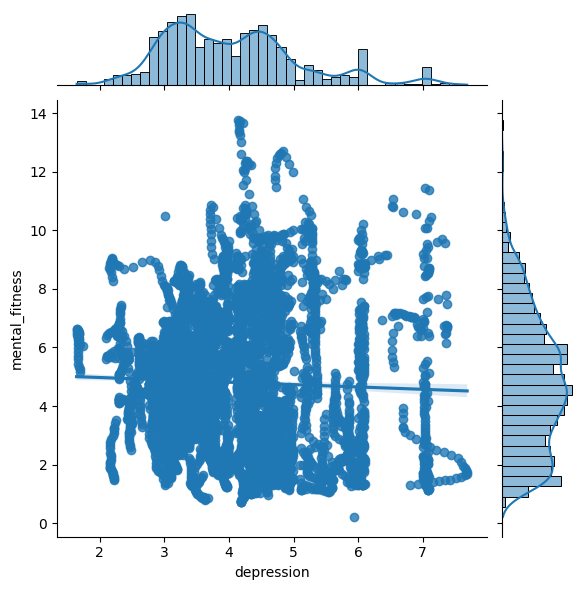

In [9]:
sns.jointplot(data=data, x='depression', y='mental_fitness', kind='reg', height=6)
plt.show()

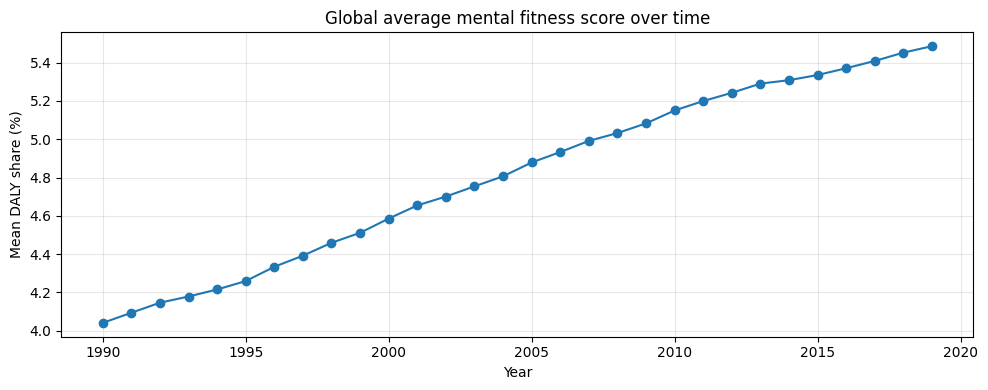

In [10]:
# how the global average moved over the years
yearly = data.groupby('year')['mental_fitness'].mean()
plt.figure(figsize=(10, 4))
plt.plot(yearly.index, yearly.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Mean DALY share (%)')
plt.title('Global average mental fitness score over time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('global_trend.png', dpi=120)
plt.show()

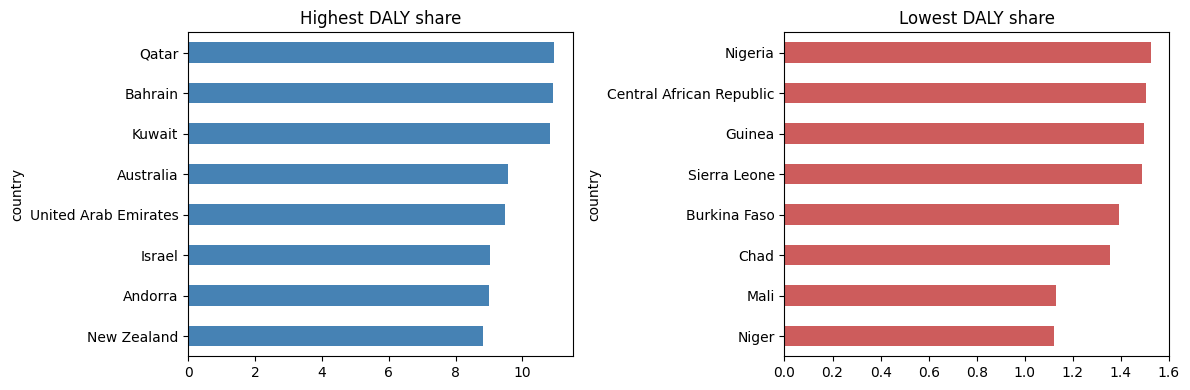

In [11]:
# countries with highest and lowest average score
avg = data.groupby('country')['mental_fitness'].mean().sort_values()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
avg.tail(8).plot(kind='barh', ax=ax[0], color='steelblue')
ax[0].set_title('Highest DALY share')
avg.head(8).plot(kind='barh', ax=ax[1], color='indianred')
ax[1].set_title('Lowest DALY share')
plt.tight_layout()
plt.show()

## Preparing data for the models

Country is text so it gets label encoded, then a standard 80/20 train test split.

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df = data.copy()
le = LabelEncoder()
df['country'] = le.fit_transform(df['country'])

X = df.drop('mental_fitness', axis=1)
y = df['mental_fitness']

xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=2)
print(xtrain.shape, xtest.shape)

(5400, 9) (1350, 9)


## Linear regression

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(model, name):
    model.fit(xtrain, ytrain)
    results = {}
    for split, xs, ys in [('train', xtrain, ytrain), ('test', xtest, ytest)]:
        pred = model.predict(xs)
        mse = mean_squared_error(ys, pred)
        results[split] = (mse, np.sqrt(mse), r2_score(ys, pred))
    print(name)
    print('-' * 40)
    for split in ['train', 'test']:
        mse, rmse, r2 = results[split]
        print('{}:  MSE={:.4f}  RMSE={:.4f}  R2={:.4f}'.format(split, mse, rmse, r2))
    print()
    return results

lr_res = evaluate(LinearRegression(), 'Linear Regression')

Linear Regression
----------------------------------------
train:  MSE=1.6388  RMSE=1.2802  R2=0.6849
test:  MSE=1.8231  RMSE=1.3502  R2=0.6699



## Random forest regression

In [14]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=0)
rf_res = evaluate(rf, 'Random Forest')

Random Forest
----------------------------------------
train:  MSE=0.0061  RMSE=0.0782  R2=0.9988
test:  MSE=0.0390  RMSE=0.1974  R2=0.9929



## Decision tree regression

In [15]:
from sklearn.tree import DecisionTreeRegressor
dt_res = evaluate(DecisionTreeRegressor(random_state=0), 'Decision Tree')

Decision Tree
----------------------------------------
train:  MSE=0.0000  RMSE=0.0000  R2=1.0000
test:  MSE=0.0978  RMSE=0.3128  R2=0.9823



## SVM regression

In [16]:
from sklearn.svm import SVR
svr_res = evaluate(SVR(), 'SVR')

SVR
----------------------------------------
train:  MSE=5.1917  RMSE=2.2785  R2=0.0017
test:  MSE=5.5588  RMSE=2.3577  R2=-0.0064



## Comparing the models

In [17]:
names = ['Linear Regression', 'Random Forest', 'Decision Tree', 'SVR']
all_res = [lr_res, rf_res, dt_res, svr_res]

comparison = pd.DataFrame({
    'model': names,
    'train_r2': [r['train'][2] for r in all_res],
    'test_r2': [r['test'][2] for r in all_res],
    'test_rmse': [r['test'][1] for r in all_res],
})
comparison

,model,train_r2,test_r2,test_rmse
0,Linear Regression,0.684872,0.669941,1.350236
1,Random Forest,0.998824,0.992945,0.197403
2,Decision Tree,1.000000,0.982288,0.312786
3,SVR,0.001706,-0.006368,2.357720


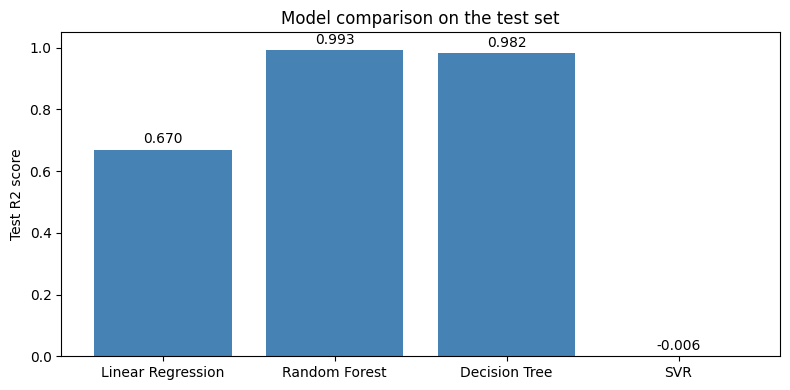

In [18]:
plt.figure(figsize=(8, 4))
plt.bar(comparison['model'], comparison['test_r2'], color='steelblue')
plt.ylabel('Test R2 score')
plt.title('Model comparison on the test set')
plt.ylim(0, 1.05)
for i, v in enumerate(comparison['test_r2']):
    plt.text(i, max(v, 0) + 0.02, '{:.3f}'.format(v), ha='center')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120)
plt.show()

## Conclusion

Random forest is clearly the best model here, with decision tree close behind.
Linear regression struggles because the relationship between the prevalence rates
and the DALY share is not linear, and SVR does poorly without feature scaling.

A tree based model picking up the non linear structure was expected, the dataset
has strong country level patterns that trees can split on directly.

## Trying it out

A small helper that takes the prevalence rates and predicts the mental fitness score using the trained random forest.

In [19]:
def predict_fitness(country, year, schizophrenia, bipolar, eating, anxiety, drugs, depression, alcohol):
    code = le.transform([country])[0]
    row = [[code, year, schizophrenia, bipolar, eating, anxiety, drugs, depression, alcohol]]
    return rf.predict(row)[0]

score = predict_fitness('India', 2019, 0.3, 0.6, 0.2, 3.5, 0.5, 3.9, 1.2)
print('Predicted mental fitness score: {:.2f}%'.format(score))

Predicted mental fitness score: 5.30%
